In [4]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# For data augmentation
import albumentations as A


In [5]:
# ============================================================
# DATASET PATHS
# ============================================================

# Root dataset directory
DATASET_PATH = "dataset/images"

# CT and MRI training folders
CT_PATH = os.path.join(DATASET_PATH, "trainA")
MRI_PATH = os.path.join(DATASET_PATH, "trainB")

print("CT path:", CT_PATH)
print("MRI path:", MRI_PATH)


CT path: dataset/images/trainA
MRI path: dataset/images/trainB


In [7]:
import os

print("CT_PATH:", CT_PATH)
print("MRI_PATH:", MRI_PATH)

print("CT files:", len(os.listdir(CT_PATH)))
print("MRI files:", len(os.listdir(MRI_PATH)))

print("First CT file:", sorted(os.listdir(CT_PATH))[:5])
print("First MRI file:", sorted(os.listdir(MRI_PATH))[:5])


CT_PATH: dataset/images/trainA
MRI_PATH: dataset/images/trainB
CT files: 1742
MRI files: 1744
First CT file: ['ct1.png', 'ct1001.png', 'ct1002.png', 'ct1003.png', 'ct1004.png']
First MRI file: ['mri1.jpg', 'mri1001.jpg', 'mri1002.jpg', 'mri1003.jpg', 'mri1004.jpg']


In [8]:
# ============================================================
# CREATE CORRECT CT–MRI PAIR MAPPING USING FILE IDS
# ============================================================

import re

def extract_id(filename):
    """Extract numeric ID from filename"""
    return int(re.findall(r'\d+', filename)[0])

# Get file lists
ct_files = os.listdir(CT_PATH)
mri_files = os.listdir(MRI_PATH)

# Create dictionaries
ct_dict = {extract_id(f): f for f in ct_files}
mri_dict = {extract_id(f): f for f in mri_files}

# Find common IDs (valid pairs)
common_ids = sorted(set(ct_dict.keys()) & set(mri_dict.keys()))

print("Total CT:", len(ct_files))
print("Total MRI:", len(mri_files))
print("Valid paired samples:", len(common_ids))


Total CT: 1742
Total MRI: 1744
Valid paired samples: 1705


CT shape: (512, 512)
MRI shape: (280, 212)


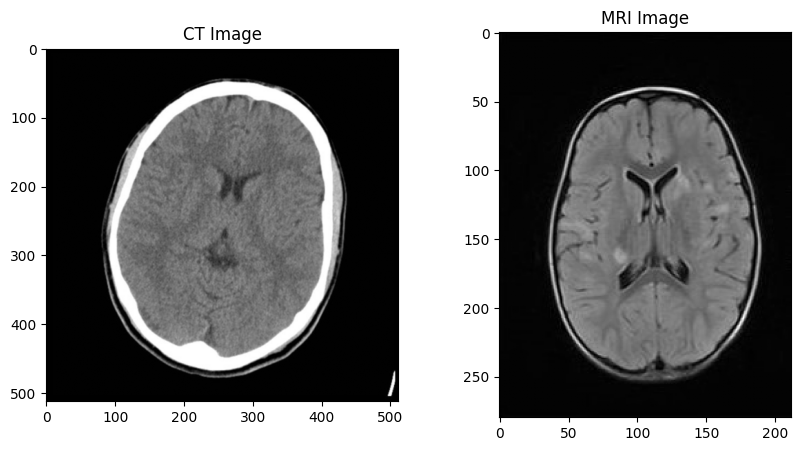

In [9]:
# ============================================================
# LOAD A CORRECTLY MATCHED PAIR
# ============================================================

sample_id = common_ids[0]

ct_img = cv2.imread(os.path.join(CT_PATH, ct_dict[sample_id]), cv2.IMREAD_GRAYSCALE)
mri_img = cv2.imread(os.path.join(MRI_PATH, mri_dict[sample_id]), cv2.IMREAD_GRAYSCALE)

print("CT shape:", ct_img.shape)
print("MRI shape:", mri_img.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_img, cmap="gray")
plt.title("CT Image")

plt.subplot(1,2,2)
plt.imshow(mri_img, cmap="gray")
plt.title("MRI Image")

plt.show()


# Creating Correct CT–MRI Pairs

In this step, we ensured proper anatomical correspondence between CT and MRI images. The dataset stores CT and MRI slices using different naming conventions (e.g., ct1.png and mri1.jpg), so direct filename matching or sorted ordering would lead to incorrect pairings.

To address this, we extracted the numeric identifier from each filename and created mappings between CT and MRI images using these IDs. Only those images that shared a common identifier were retained, ensuring that each CT image was paired with its corresponding MRI slice.

Images without a matching counterpart in the other modality were excluded from further processing. This step guarantees that subsequent preprocessing, augmentation, and model training operate on correctly aligned multi-modal anatomical data.

In [10]:
# ============================================================
# NORMALIZATION FUNCTION
# Normalizes each modality independently to range [0,1]
# ============================================================

def normalize_image(img):
    """
    Convert image to float and scale values between 0 and 1.
    This is done separately for CT and MRI because their
    intensity distributions are fundamentally different.
    """
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)


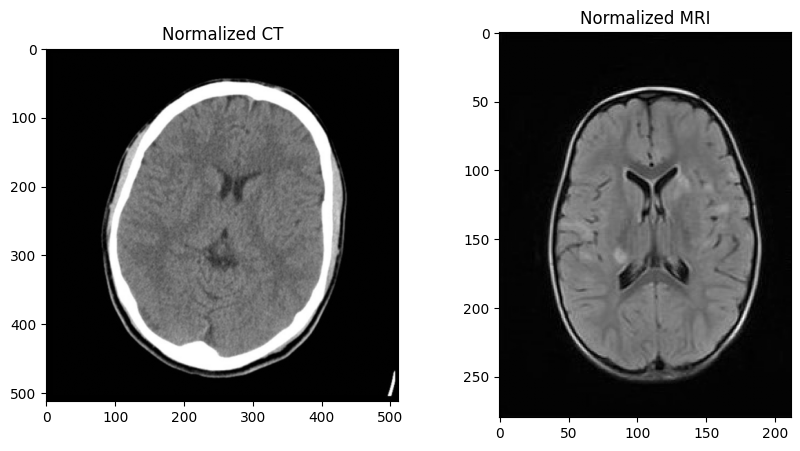

CT range: 0.0 to 1.0
MRI range: 0.0 to 1.0


In [11]:
# ============================================================
# TEST NORMALIZATION ON ONE PAIR
# ============================================================

ct_norm = normalize_image(ct_img)
mri_norm = normalize_image(mri_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_norm, cmap="gray")
plt.title("Normalized CT")

plt.subplot(1,2,2)
plt.imshow(mri_norm, cmap="gray")
plt.title("Normalized MRI")

plt.show()

print("CT range:", ct_norm.min(), "to", ct_norm.max())
print("MRI range:", mri_norm.min(), "to", mri_norm.max())


CT and MRI images were normalized independently using min-max scaling to ensure each modality retained its unique intensity characteristics while bringing pixel values into a consistent range for stable neural network training.

In [12]:
# ============================================================
# RESIZE & ALIGNMENT FUNCTION
# Ensures CT and MRI have identical spatial dimensions
# ============================================================

def resize_pair(ct, mri, size=(256, 256)):
    """
    Resize CT and MRI images to a common resolution.

    This step is necessary because deep learning models require
    fixed-size inputs, and resizing ensures both modalities
    remain spatially aligned for accurate multi-modal learning.
    """
    ct_resized = cv2.resize(ct, size, interpolation=cv2.INTER_AREA)
    mri_resized = cv2.resize(mri, size, interpolation=cv2.INTER_AREA)
    
    return ct_resized, mri_resized


CT resized shape: (256, 256)
MRI resized shape: (256, 256)


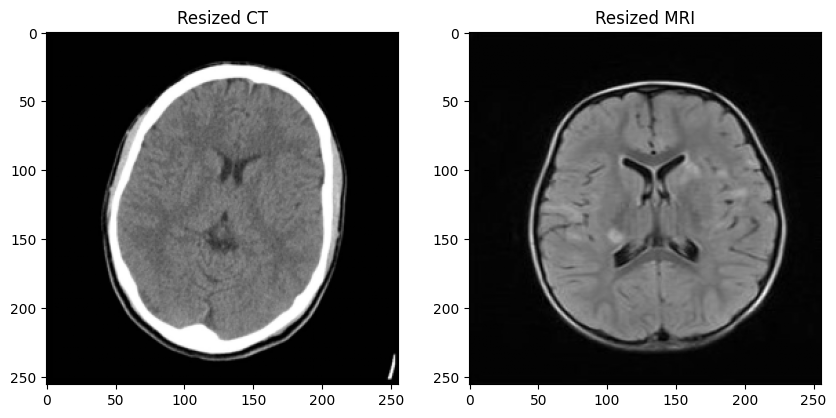

In [13]:
# ============================================================
# TEST RESIZE FUNCTION
# ============================================================

ct_resized, mri_resized = resize_pair(ct_norm, mri_norm)

print("CT resized shape:", ct_resized.shape)
print("MRI resized shape:", mri_resized.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_resized, cmap="gray")
plt.title("Resized CT")

plt.subplot(1,2,2)
plt.imshow(mri_resized, cmap="gray")
plt.title("Resized MRI")

plt.show()


To ensure compatibility with deep learning models, CT and MRI images were resized to a uniform spatial resolution. This step guarantees that both modalities share identical dimensions, preserving anatomical correspondence while enabling efficient batch processing during model training.

In [15]:
# ============================================================
# DATA AUGMENTATION PIPELINE (UPDATED - USING AFFINE)
# ============================================================

"""
This augmentation pipeline applies synchronized transformations
to both CT and MRI images to maintain anatomical correspondence.

Includes:
- Spatial distortions (rotation, scaling, translation)
- Intensity variations
"""

augment = A.Compose([
    
    # Spatial distortions using Affine transform
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.05, 0.05),
        rotate=(-10, 10),
        p=0.5
    ),
    
    # Intensity variation
    A.RandomBrightnessContrast(p=0.5),
    
], additional_targets={'mri': 'image'})


In [16]:
# ============================================================
# RANDOM NOISE INJECTION
# ============================================================

def add_noise(img, noise_level=0.02):
    """
    Adds Gaussian noise to simulate scanner noise.
    Improves robustness of anomaly detection models.
    """
    noise = np.random.normal(0, noise_level, img.shape)
    noisy_img = img + noise
    return np.clip(noisy_img, 0, 1)


In [17]:
# ============================================================
# APPLY AUGMENTATION TO CT–MRI PAIRS
# ============================================================

def augment_pair(ct, mri):
    
    # Apply paired augmentation
    augmented = augment(image=ct, mri=mri)
    
    ct_aug = augmented["image"]
    mri_aug = augmented["mri"]
    
    # Add noise separately to each modality
    ct_aug = add_noise(ct_aug)
    mri_aug = add_noise(mri_aug)
    
    return ct_aug, mri_aug


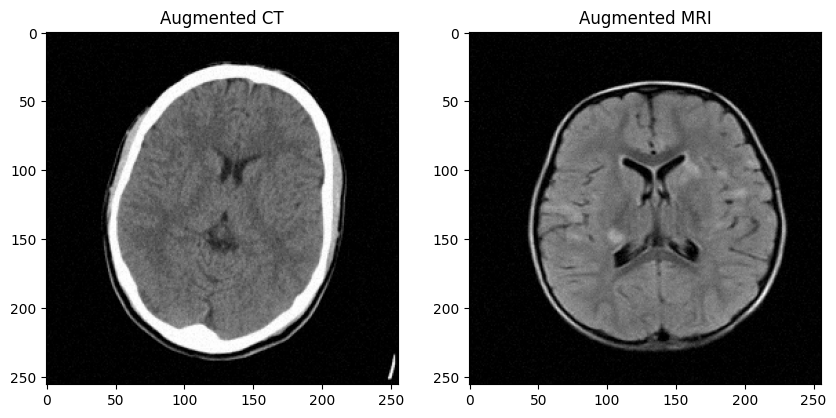

In [18]:
# ============================================================
# TEST AUGMENTATION PIPELINE
# ============================================================

ct_aug, mri_aug = augment_pair(ct_resized, mri_resized)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_aug, cmap="gray")
plt.title("Augmented CT")

plt.subplot(1,2,2)
plt.imshow(mri_aug, cmap="gray")
plt.title("Augmented MRI")

plt.show()


To improve model robustness and generalization, paired data augmentation was applied to CT and MRI images. Spatial transformations such as rotation, scaling, and shifting were applied synchronously to both modalities to preserve anatomical alignment. Additionally, intensity variations and Gaussian noise injection were introduced to simulate real-world imaging variability and scanner noise.

In [19]:
# ============================================================
# COMPLETE PREPROCESSING PIPELINE FUNCTION
# ============================================================

def preprocess_pair(ct, mri):
    """
    Complete preprocessing pipeline for paired CT–MRI images.

    Steps performed:
    1. Independent normalization of CT and MRI
    2. Resize and spatial alignment
    3. Paired data augmentation using affine transforms
    4. Random noise injection

    Returns:
        Preprocessed CT and MRI images ready for model input.
    """
    
    # Step 1: Normalize independently
    ct = normalize_image(ct)
    mri = normalize_image(mri)
    
    # Step 2: Resize & align
    ct, mri = resize_pair(ct, mri)
    
    # Step 3: Apply paired augmentation
    augmented = augment(image=ct, mri=mri)
    ct = augmented["image"]
    mri = augmented["mri"]
    
    # Step 4: Add noise injection
    ct = add_noise(ct)
    mri = add_noise(mri)
    
    return ct, mri


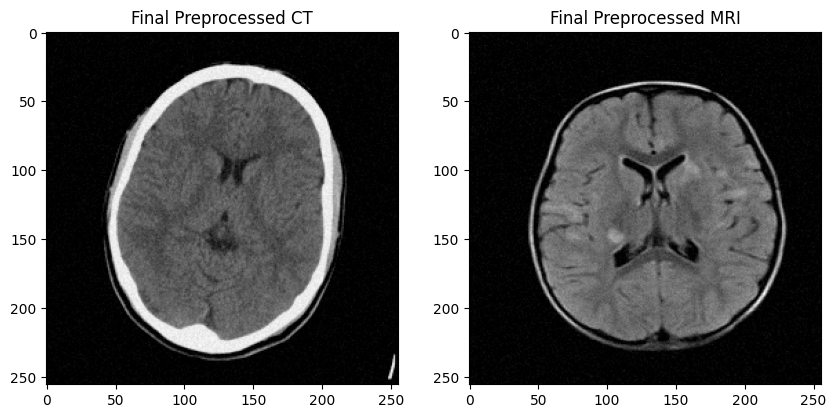

CT range: 0.0 to 0.8576981409710456
MRI range: 0.0 to 0.7621429774472355


In [20]:
# ============================================================
# TEST COMPLETE PREPROCESSING PIPELINE
# ============================================================

ct_final, mri_final = preprocess_pair(ct_img, mri_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct_final, cmap="gray")
plt.title("Final Preprocessed CT")

plt.subplot(1,2,2)
plt.imshow(mri_final, cmap="gray")
plt.title("Final Preprocessed MRI")

plt.show()

print("CT range:", ct_final.min(), "to", ct_final.max())
print("MRI range:", mri_final.min(), "to", mri_final.max())


A comprehensive preprocessing pipeline was developed for paired CT and MRI brain images. Each modality was independently normalized to account for differing intensity distributions. The images were then resized to a common spatial resolution to ensure anatomical alignment. Paired data augmentation was applied using affine transformations to preserve spatial correspondence across modalities, along with intensity variations to simulate imaging variability. Finally, Gaussian noise injection was introduced to enhance model robustness against scanner noise. Due to interpolation during affine transformations and intensity augmentations, the final pixel values may not span the full [0,1] range. This is expected and does not affect model training.